# NB03 — WTI Volatility: Pipeline de Sentimiento FinBERT
## Recolección · Scoring · Alineación Temporal · Exportación

**Proyecto:** Benchmark GARCH / LSTM / Híbrido para detección de volatilidad extrema WTI  
**Input:** GDELT Project (gratuito) + EIA Weekly Reports (respaldo)  
**Output:** `wti_sentiment_finbert.csv` → usado en NB02 Parte V

---

## Índice
0. Instalación y configuración  
1. Descarga de titulares (GDELT)  
2. Respaldo: EIA Weekly Reports  
3. Limpieza y deduplicación  
4. Scoring con FinBERT  
5. Agregación diaria  
6. Alineación temporal (shift anti-leakage)  
7. Análisis exploratorio del sentimiento  
8. Exportación

---

> **Nota sobre data leakage**: El sentimiento del día t se desplaza 1 día hacia adelante
> antes de mergearse con las features de volatilidad. El modelo en NB02 usa
> `sentiment_score(t-1)` para predecir `is_extreme(t+1)` — no hay información del futuro.

## 0. Instalación y Configuración

### Nota metodológica (actualizada)
- **GDELT no implica cobertura equivalente desde 2000**: para años tempranos se debe marcar `low_confidence`/`unsupported`.
- Este notebook separa explícitamente **noticia textual real** vs **imputación**.
- `train` y `validation` son configurables; `test` queda fijo por defecto para comparabilidad con benchmarks previos.
- Si la cobertura real en train/validation es insuficiente, el pipeline marca `SKIPPED_INSUFFICIENT_COVERAGE`.



In [1]:
# gdeltdoc: cliente oficial de GDELT Project
# transformers: FinBERT (ProsusAI/finbert)
# torch: backend para inferencia FinBERT
# sentencepiece: tokenizador BERT

#  0.1 Instalación de dependencias
# Fijar pandas a versión compatible con Colab antes de instalar gdeltdoc
!pip install "pandas==2.2.2" gdeltdoc transformers torch sentencepiece -q

# Verificar versiones
import pandas as pd
import transformers
print(f"pandas      : {pd.__version__}   (requerido: <3.0.0)")
print(f"transformers: {transformers.__version__}")

# Guard de versión
assert pd.__version__.startswith('2.'), \
    f"pandas {pd.__version__} incompatible — REINICIA EL RUNTIME (Entorno de ejecución > Reiniciar sesión) y vuelve a ejecutar."
print("Dependencias OK ✓")

pandas      : 2.2.2   (requerido: <3.0.0)
transformers: 5.0.0
Dependencias OK ✓


In [2]:
# ─── 0.2 Imports ──────────────────────────────────────────────
import sys, os, json, random, re, time, warnings, pickle
from datetime import datetime, timedelta
from pathlib import Path

import numpy  as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

#  Estilo IEEE
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'legend.fontsize': 9,
    'figure.dpi': 300, 'savefig.dpi': 300,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': ':',
    'axes.edgecolor': 'black', 'axes.linewidth': 0.8,
})

RANDOM_SEED = 42
random.seed(RANDOM_SEED)      # Python — para shuffle si lo hay
np.random.seed(RANDOM_SEED)   # NumPy — para operaciones de muestreo
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)  # orden interno Python
import torch
torch.manual_seed(RANDOM_SEED)

print('Imports OK')
print(f'Python  : {sys.version.split()[0]}')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Imports OK
Python  : 3.12.12
Pandas  : 2.2.2
NumPy   : 2.0.2


In [3]:
# ─── 0.3 Configuración de rutas y ventanas temporales ────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    BASE_PATH = "/content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos"
    FIG_PATH  = f"{BASE_PATH}/Fig_NB03"
else:
    BASE_PATH = "."
    FIG_PATH  = "."

os.makedirs(FIG_PATH, exist_ok=True)

CONFIG_PATH   = f"{BASE_PATH}/config_estudio_FINAL.json"
CSV_CLEAN     = f"{BASE_PATH}/wti_volatilidad_CLEAN.csv"
OUTPUT_SENT   = f"{BASE_PATH}/wti_sentiment_finbert.csv"
CACHE_RAW     = f"{BASE_PATH}/wti_gdelt_raw_2017_2026.csv"

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = json.load(f)

# Ventana benchmark (NO cambiar salvo override explícito)
BENCHMARK_TEST_START = str(config['fechas']['test_start'])
BENCHMARK_TEST_END   = str(config['fechas']['end_date'])
ALLOW_TEST_OVERRIDE  = bool(int(os.getenv('NB03_ALLOW_TEST_OVERRIDE', '0')))

# Ventana de noticias y splits configurables por entorno
NEWS_START_DATE = os.getenv('NB03_NEWS_START_DATE', config['fechas']['start_date'])
NEWS_END_DATE   = os.getenv('NB03_NEWS_END_DATE',   config['fechas']['end_date'])
TRAIN_END       = os.getenv('NB03_TRAIN_END',       config['fechas']['train_end'])
VAL_START       = os.getenv('NB03_VAL_START',       config['fechas']['val_start'])
VAL_END         = os.getenv('NB03_VAL_END',         config['fechas']['val_end'])
TEST_START      = os.getenv('NB03_TEST_START',      BENCHMARK_TEST_START)
TEST_END        = os.getenv('NB03_TEST_END',        BENCHMARK_TEST_END)


def validate_split_config(train_end, val_start, val_end, test_start, test_end, allow_test_override=False):
    te = pd.Timestamp(train_end)
    vs = pd.Timestamp(val_start)
    ve = pd.Timestamp(val_end)
    ts = pd.Timestamp(test_start)
    tx = pd.Timestamp(test_end)

    if not (te < vs <= ve < ts <= tx):
        raise ValueError(
            'Splits inválidos. Se requiere train_end < val_start <= val_end < test_start <= test_end.'
        )

    benchmark_fixed = (str(test_start)[:10] == BENCHMARK_TEST_START[:10]) and (str(test_end)[:10] == BENCHMARK_TEST_END[:10])
    if (not benchmark_fixed) and (not allow_test_override):
        raise ValueError(
            f'Test benchmark fijo en {BENCHMARK_TEST_START}→{BENCHMARK_TEST_END}. '
            'Define NB03_ALLOW_TEST_OVERRIDE=1 para cambiarlo explícitamente.'
        )
    return benchmark_fixed

TEST_MATCHES_BENCHMARK = validate_split_config(
    TRAIN_END, VAL_START, VAL_END, TEST_START, TEST_END, allow_test_override=ALLOW_TEST_OVERRIDE
)

splits = [
    ('train', NEWS_START_DATE, TRAIN_END),
    ('validation', VAL_START, VAL_END),
    ('test', TEST_START, TEST_END),
]

print(f'BASE_PATH: {BASE_PATH}')
print(f'NEWS RANGE solicitado: {NEWS_START_DATE} → {NEWS_END_DATE}')
print('Splits configurados:')
for name, s, e in splits:
    print(f'  - {name:<10}: {s} → {e}')
print(f'Test benchmark fijo: {TEST_MATCHES_BENCHMARK}')


Mounted at /content/drive
BASE_PATH : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos
Período   : 2000-01-01 → 2026-02-28
Config cargado ✓


---
## PARTE I — Descarga de Titulares (GDELT)

> **GDELT Project** (gdeltproject.org): base de datos global de noticias, gratuita y de acceso público.
> Indexa titulares de miles de medios en tiempo real desde 1979.
> API disponible vía `gdeltdoc` (Python) sin autenticación.
>
> **Estrategia de descarga**: queries por bloques de 3 meses para respetar
> los límites de la API (~250 artículos por query). El caché local evita
> re-descargas en ejecuciones posteriores.

In [4]:
# ─── 1.1 Configuración de extracción de noticias (arquitectura pluggable) ─────
from news_sources import build_news_sources, fetch_news_from_sources

SEARCH_TERMS = [
    'WTI crude oil',
    'oil price volatility',
]

DOMAINS = [
    'reuters.com', 'bloomberg.com', 'wsj.com', 'ft.com',
    'cnbc.com', 'marketwatch.com', 'oilprice.com',
]

NEWS_SOURCE_MODE = os.getenv('NB03_NEWS_SOURCE_MODE', 'auto').strip().lower()
HISTORICAL_NEWS_CSV = os.getenv('NB03_HISTORICAL_NEWS_CSV', '').strip()

news_sources = build_news_sources(
    mode=NEWS_SOURCE_MODE,
    cache_path=CACHE_RAW,
    domains=DOMAINS,
    historical_csv_path=HISTORICAL_NEWS_CSV,
)

print('Modo de fuentes:', NEWS_SOURCE_MODE)
print('Fuentes activas:', [s.provider for s in news_sources])
if NEWS_SOURCE_MODE == 'gdelt_only':
    print('⚠️ Modo GDELT-only: cobertura pre-2017 será considerada NO equivalente/low-confidence.')


Términos de búsqueda configurados:
  - WTI crude oil
  - oil price volatility

Dominios preferidos: 7


In [5]:
# ─── 1.2 Descarga/fetch por proveedor (red sólo en esta etapa) ─────────────────
news_df, source_meta = fetch_news_from_sources(
    sources=news_sources,
    search_terms=SEARCH_TERMS,
    start_date=NEWS_START_DATE,
    end_date=NEWS_END_DATE,
)

if news_df.empty:
    print('⚠️ No se encontraron noticias textuales para el rango solicitado.')
else:
    print(f'Noticias consolidadas: {len(news_df):,}')
    print(f'Rango efectivo: {news_df.date.min().date()} → {news_df.date.max().date()}')
    print('Conteo por provider:')
    print(news_df['provider'].value_counts())

df_raw = news_df.copy()


Cache encontrado: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/wti_gdelt_raw_2017_2026.csv
  14,818 artículos cargados

Columnas: ['url', 'url_mobile', 'title', 'seendate', 'socialimage', 'domain', 'language', 'sourcecountry']


,url,url_mobile,title,seendate,socialimage,domain,language,sourcecountry
0,http://forextv.com/market-news/european-shares...,NaN,European Shares Set For Sluggish Start,2017-03-17 07:45:00+00:00,NaN,forextv.com,English,United States
1,http://www.environmentguru.com/pages/elements/...,NaN,4 Factors Driving Oil Prices This Summer,2017-03-28 04:30:00+00:00,NaN,environmentguru.com,English,United States
2,http://www.engineeringnews.co.za/article/west-...,NaN,West African gold mine signs solar power agree...,2017-03-06 23:45:00+00:00,http://us-cdn.creamermedia.co.za/assets/articl...,engineeringnews.co.za,English,South Africa


In [6]:
if Path(CACHE_RAW).exists():
    df_raw = pd.read_csv(CACHE_RAW)
    if df_raw.empty:
        print("[WARN] Cache GDELT vacío detectado. Forzando refresh recomendado.")

---
## PARTE II — Respaldo: EIA Weekly Petroleum Reports

> La Energy Information Administration (EIA) publica reportes semanales de
> inventarios de petróleo crudo en EEUU — un driver fundamental de los
> movimientos de precio del WTI. Son datos estructurados, no titulares,
> pero tienen sentimiento implícito: un inventario mayor al esperado es
> bajista (bearish), menor es alcista (bullish).
>
> Se usa como **fuente de respaldo** para semanas sin cobertura GDELT,
> y como **feature adicional** (`inventory_surprise`) en el modelo híbrido.

In [7]:
# Seguridad: NO hardcodear credenciales
# EIA_API_KEY se lee exclusivamente desde variable de entorno.
EIA_API_KEY = os.getenv('EIA_API_KEY', '').strip()
if EIA_API_KEY:
    print('EIA_API_KEY detectada por entorno (valor oculto).')
else:
    print('EIA_API_KEY no definida en entorno. Se omite descarga EIA.')


In [8]:
# ─── 2.1 Descarga EIA Weekly Petroleum Report (opcional, no sustituye news textual) ──
EIA_CACHE = f"{BASE_PATH}/eia_inventory_raw.csv"

if os.path.exists(EIA_CACHE):
    print(f'Cargando caché EIA: {EIA_CACHE}')
    df_eia = pd.read_csv(EIA_CACHE, parse_dates=['date'])
    print(f'  Observaciones EIA: {len(df_eia):,}')

elif EIA_API_KEY:
    import requests
    url = (
        'https://api.eia.gov/v2/petroleum/sum/sndw/data/'
        f'?api_key={EIA_API_KEY}'
        '&frequency=weekly&data[0]=value'
        '&facets[series][]=WCRSTUS1'
        '&start=1999-01-01'
        f'&end={pd.Timestamp(NEWS_END_DATE).strftime("%Y-%m-%d")}'
        '&sort[0][column]=period&sort[0][direction]=asc'
        '&offset=0&length=5000'
    )
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()
    except Exception as exc:
        print(f'Error consultando EIA: {repr(exc)}')
        data = {}

    if 'response' in data and 'data' in data['response']:
        df_eia = pd.DataFrame(data['response']['data'])
        df_eia.rename(columns={'period': 'date', 'value': 'inventory_kbbl'}, inplace=True)
        df_eia['date'] = pd.to_datetime(df_eia['date'])
        df_eia['inventory_kbbl'] = pd.to_numeric(df_eia['inventory_kbbl'], errors='coerce')
        df_eia = df_eia.sort_values('date').reset_index(drop=True)
        df_eia['inventory_change'] = df_eia['inventory_kbbl'].diff()
        roll_mean = df_eia['inventory_change'].rolling(52).mean()
        roll_std = df_eia['inventory_change'].rolling(52).std()
        df_eia['inventory_surprise_zscore'] = (df_eia['inventory_change'] - roll_mean) / roll_std
        df_eia.to_csv(EIA_CACHE, index=False)
        print(f'EIA descargado: {len(df_eia):,} observaciones')
    else:
        print('⚠️ EIA sin datos válidos. Continuamos sin EIA (no afecta pipeline textual).')
        df_eia = pd.DataFrame(columns=['date', 'inventory_kbbl', 'inventory_change', 'inventory_surprise_zscore'])
else:
    df_eia = pd.DataFrame(columns=['date', 'inventory_kbbl', 'inventory_change', 'inventory_surprise_zscore'])

print(f'df_eia: {len(df_eia):,} observaciones')


Cargando caché EIA: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/eia_inventory_raw.csv
  Observaciones EIA: 1,418

df_eia: 1,418 observaciones


---
## PARTE III — Limpieza y Deduplicación de Titulares

In [9]:
# ─── 3.1 Limpieza de titulares (estándar multi-proveedor) ─────────────────────
df = df_raw.copy()

if df.empty:
    raise ValueError('No hay noticias en df_raw. Revisar rango/credenciales/fuentes.')

# Normalización defensiva
for col in ['date', 'headline', 'source_name', 'url', 'provider', 'coverage_quality']:
    if col not in df.columns:
        df[col] = ''

df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
df['headline'] = df['headline'].astype(str).str.replace(r'<[^>]+>', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()

# Filtrado de calidad mínima
n_before = len(df)
df = df[df['headline'].str.len() >= 10]
df = df.dropna(subset=['date'])
df = df.drop_duplicates(subset=['date', 'headline', 'provider'])
df = df[(df['date'] >= pd.Timestamp(NEWS_START_DATE)) & (df['date'] <= pd.Timestamp(NEWS_END_DATE))]
print(f'Filtrado titulares: {n_before:,} → {len(df):,}')

# Cobertura quality explícita
df['is_actual_text_news'] = (df['coverage_quality'] == 'actual_news').astype(int)

print('Cobertura temporal de noticias textuales:')
print(f'  Primera noticia: {df.date.min().date()}')
print(f'  Última noticia : {df.date.max().date()}')
print('Provider x quality:')
print(df.groupby(['provider', 'coverage_quality']).size().sort_values(ascending=False).head(10))


Filtro idioma inglés: 14,818 → 11,602
Filtro headlines cortos: 11,602 → 11,371
Deduplicación: 11,371 → 9,299
Filtro período 2000-01-01–2026-02-28: 9,299 → 9,299

Cobertura temporal:
  Primera noticia: 2017-01-02
  Última noticia:  2026-02-27
  Días con cobertura: 2,729
  Media titulares/día: 3.4


In [10]:
# ─── 3.2 Diagnóstico metodológico: cobertura por split/año y soporte real ──────
df_wti = pd.read_csv(CSV_CLEAN, index_col=0, parse_dates=True)
trading_days = pd.Series(df_wti.index.normalize().unique(), name='date')
news_days_all = pd.Series(pd.to_datetime(df['date'].unique()), name='date')
news_days_actual = pd.Series(pd.to_datetime(df.loc[df['is_actual_text_news'] == 1, 'date'].unique()), name='date')

coverage_rows = []
print('Cobertura por split (trading vs noticias textuales):')
print(f'{"Split":<12} {"Trading":>10} {"Con noticias":>14} {"Con news real":>14} {"Cobertura real %":>16}')
print('─' * 78)
for name, s, e in splits:
    td = trading_days[(trading_days >= s) & (trading_days <= e)]
    nd = news_days_all[(news_days_all >= s) & (news_days_all <= e)]
    na = news_days_actual[(news_days_actual >= s) & (news_days_actual <= e)]
    real_cov = len(set(td) & set(na)) / len(td) if len(td) else 0.0
    coverage_rows.append({
        'split': name,
        'trading_days': int(len(td)),
        'news_days_any': int(len(set(td) & set(nd))),
        'news_days_actual': int(len(set(td) & set(na))),
        'coverage_real_pct': round(real_cov * 100, 2),
    })
    print(f'{name:<12} {len(td):>10,} {len(set(td)&set(nd)):>14,} {len(set(td)&set(na)):>14,} {real_cov*100:>15.2f}%')

coverage_split_df = pd.DataFrame(coverage_rows)

# Cobertura anual por proveedor/quality (auditoría 2000→latest)
all_trading_by_year = trading_days.groupby(trading_days.dt.year).nunique()
actual_by_year = pd.Series(pd.to_datetime(df.loc[df['is_actual_text_news']==1, 'date']).dt.year).value_counts().sort_index()

coverage_year_df = pd.DataFrame({'trading_days': all_trading_by_year}).fillna(0)
coverage_year_df['actual_news_days'] = coverage_year_df.index.map(actual_by_year).fillna(0).astype(int)
coverage_year_df['actual_coverage_pct'] = (coverage_year_df['actual_news_days'] / coverage_year_df['trading_days'] * 100).round(2)
coverage_year_df['coverage_status'] = np.select(
    [coverage_year_df['actual_coverage_pct'] >= 30, coverage_year_df['actual_coverage_pct'] > 0],
    ['actual_news', 'low_confidence'],
    default='unsupported'
)
low_coverage_years = coverage_year_df.index[coverage_year_df['actual_coverage_pct'] < 30].tolist()

SUPPORTED_FROM_DATE = None
if not df.loc[df['is_actual_text_news']==1].empty:
    SUPPORTED_FROM_DATE = str(df.loc[df['is_actual_text_news']==1, 'date'].min().date())

print('
Resumen anual (últimos 15 años):')
display(coverage_year_df.tail(15))

if pd.Timestamp(NEWS_START_DATE) < pd.Timestamp('2017-01-01') and NEWS_SOURCE_MODE == 'gdelt_only':
    print('⚠️ Advertencia metodológica: GDELT-only no soporta cobertura equivalente para 2000-2016.')


Cobertura de titulares por split:
Split         Días trading  Días con noticias  Cobertura %
────────────────────────────────────────────────────────────
train                4,584                590         0.0%
validation             483                624         0.0%
test                 1,296              1,513         0.0%

Días de trading sin cobertura (requieren imputación): 4,322
→ Se imputarán con forward-fill (last known sentiment)


---
## PARTE IV — Scoring con FinBERT

> **FinBERT** (Araci, 2019 — `ProsusAI/finbert`): BERT preentrenado en
> textos financieros. Clasifica cada titular en:
> - `positive` → alcista (bullish)
> - `negative` → bajista (bearish)  
> - `neutral`  → sin dirección clara
>
> El score neto por día se define como:
> `sentiment_score = mean(P(positive) − P(negative))` sobre todos los titulares del día.
>
> **Procesamiento en batches** para evitar OOM en Colab (batch_size=32).

In [11]:
# ─── 4.1 Cargar modelo FinBERT ────────────────────────────────
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.nn.functional import softmax

FINBERT_MODEL = 'ProsusAI/finbert'
FINBERT_CACHE = f"{BASE_PATH}/finbert_scores_cache.pkl"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL)
model_fb  = BertForSequenceClassification.from_pretrained(FINBERT_MODEL)
model_fb  = model_fb.to(device)
model_fb.eval()

# FinBERT: índices de clase
# 0=positive, 1=negative, 2=neutral (verificar con model_fb.config.id2label)
print(f'Labels FinBERT: {model_fb.config.id2label}')
LABEL_POS = [k for k, v in model_fb.config.id2label.items() if 'positive' in v.lower()][0]
LABEL_NEG = [k for k, v in model_fb.config.id2label.items() if 'negative' in v.lower()][0]
print(f'  Índice positive: {LABEL_POS} | Índice negative: {LABEL_NEG}')

Dispositivo: cuda


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labels FinBERT: {0: 'positive', 1: 'negative', 2: 'neutral'}
  Índice positive: 0 | Índice negative: 1


In [12]:
# ─── 4.2 Función de scoring en batches ────────────────────────
def score_headlines_batch(headlines, batch_size=32, max_length=128):
    """
    Puntúa una lista de titulares con FinBERT.
    Retorna array de shape (N, 3) con probabilidades [pos, neg, neutral].

    Parámetros
    ----------
    headlines  : list[str]
    batch_size : int — titulares por forward pass (32 seguro en Colab T4)
    max_length : int — truncar titulares largos (BERT max=512, 128 suficiente)

    Retorna
    -------
    np.ndarray (N, 3) — [P(pos), P(neg), P(neutral)] por titular
    """
    all_probs = []

    for i in range(0, len(headlines), batch_size):
        batch = headlines[i : i + batch_size]
        # Truncar a max_length tokens
        encoded = tokenizer(
            batch,
            padding    = True,
            truncation = True,
            max_length = max_length,
            return_tensors = 'pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            logits = model_fb(**encoded).logits
            probs  = softmax(logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

        if (i // batch_size) % 50 == 0:
            pct = min(i + batch_size, len(headlines)) / len(headlines) * 100
            print(f'  Scoring: {pct:.0f}% ({i+batch_size:,}/{len(headlines):,})',
                  end='\r')

    return np.vstack(all_probs)   # (N, 3)

print('score_headlines_batch() definida')

score_headlines_batch() definida


In [13]:
# ─── 4.3 Ejecutar FinBERT (con caché) ─────────────────────────
# El caché pkl evita re-ejecutar FinBERT en runs posteriores
# (puede tardar 30-90 minutos según GPU y volumen de titulares)

if os.path.exists(FINBERT_CACHE):
    print(f'Cargando caché FinBERT: {FINBERT_CACHE}')
    with open(FINBERT_CACHE, 'rb') as fh:
        probs_all = pickle.load(fh)
    print(f'  Scores cargados: {probs_all.shape}')
else:
    print(f'Ejecutando FinBERT sobre {len(df):,} titulares...')
    print('(GPU recomendado — en CPU puede tardar varias horas)\n')

    headlines_list = df['headline'].tolist()
    probs_all = score_headlines_batch(headlines_list, batch_size=32)

    with open(FINBERT_CACHE, 'wb') as fh:
        pickle.dump(probs_all, fh)
    print(f'\nFinBERT completado. Caché guardado: {FINBERT_CACHE}')

# Asignar probabilidades al DataFrame
df['p_positive'] = probs_all[:, LABEL_POS]
df['p_negative'] = probs_all[:, LABEL_NEG]
LABEL_NEU = [k for k, v in model_fb.config.id2label.items()
             if 'neutral' in v.lower()][0]
df['p_neutral'] = probs_all[:, LABEL_NEU]
# Score neto por titular: P(pos) - P(neg) ∈ [-1, 1]
df['sentiment_net'] = df['p_positive'] - df['p_negative']

# Clase predicha
df['sentiment_label'] = df[['p_positive','p_negative','p_neutral']].idxmax(axis=1)
df['sentiment_label'] = df['sentiment_label'].str.replace('p_', '')

print('\nDistribución de clases FinBERT:')
print(df['sentiment_label'].value_counts())
print(f'\nScore neto — media: {df["sentiment_net"].mean():.4f} | '
      f'std: {df["sentiment_net"].std():.4f}')

df[['date', 'headline', 'p_positive', 'p_negative', 'sentiment_net',
    'sentiment_label']].head(5)

Cargando caché FinBERT: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/finbert_scores_cache.pkl
  Scores cargados: (9299, 3)

Distribución de clases FinBERT:
sentiment_label
neutral     4693
negative    2650
positive    1956
Name: count, dtype: int64

Score neto — media: -0.0620 | std: 0.5512


,date,headline,p_positive,p_negative,sentiment_net,sentiment_label
0,2017-03-17 00:00:00+00:00,European Shares Set For Sluggish Start,0.030364,0.904198,-0.873834,negative
1,2017-03-28 00:00:00+00:00,4 Factors Driving Oil Prices This Summer,0.039142,0.052819,-0.013677,neutral
2,2017-03-06 00:00:00+00:00,West African gold mine signs solar power agree...,0.595059,0.011693,0.583366,positive
7,2017-01-13 00:00:00+00:00,‘ Significant ’ oil supply,0.223245,0.046575,0.176670,neutral
8,2017-01-13 00:00:00+00:00,Significant oil supply,0.115396,0.019834,0.095561,neutral


---
## PARTE V — Agregación Diaria

> Por cada día de trading se agregan todos los titulares del día
> en un conjunto de features escalares:
>
> | Feature | Descripción |
> |---|---|
> | `sentiment_score` | Media de P(pos)−P(neg) — señal principal |
> | `sentiment_std` | Desviación estándar del sentimiento — dispersión intradiaria |
> | `n_articles` | Número de titulares — proxy de atención mediática |
> | `pct_positive` | % de titulares positivos |
> | `pct_negative` | % de titulares negativos |
> | `sentiment_flag` | 1 si hay titulares reales; 0 si imputado con ffill |

In [14]:
# ─── 5.1 Agregación diaria ────────────────────────────────────
daily = df.groupby('date').agg(
    sentiment_score = ('sentiment_net',   'mean'),
    sentiment_std   = ('sentiment_net',   'std'),
    n_articles      = ('sentiment_net',   'count'),
    pct_positive    = ('sentiment_label', lambda x: (x == 'positive').mean()),
    pct_negative    = ('sentiment_label', lambda x: (x == 'negative').mean()),
).reset_index()

# Días con solo 1 artículo tienen std=NaN → imputar con 0
daily['sentiment_std'] = daily['sentiment_std'].fillna(0)

# Flag: 1 = datos reales, 0 = será imputado
daily['sentiment_flag'] = 1
daily['date'] = pd.to_datetime(daily['date'])

print(f'Días con cobertura real: {len(daily):,}')
print(f'Score medio: {daily["sentiment_score"].mean():.4f}')
print(f'Artículos por día — media: {daily["n_articles"].mean():.1f} '
      f'| max: {daily["n_articles"].max()}')
daily.head(3)

Días con cobertura real: 2,729
Score medio: -0.0701
Artículos por día — media: 3.4 | max: 33


,date,sentiment_score,sentiment_std,n_articles,pct_positive,pct_negative,sentiment_flag
0,2017-01-02 00:00:00+00:00,0.562960,0.390949,2,1.000000,0.000000,1
1,2017-01-03 00:00:00+00:00,0.236278,0.733232,5,0.600000,0.200000,1
2,2017-01-04 00:00:00+00:00,0.514854,0.215096,3,0.666667,0.000000,1


In [15]:
# ─── 5.2 Alineación a trading days + imputación causal + usabilidad ───────────
required_cols = ['sentiment_score', 'sentiment_std', 'n_articles', 'pct_positive', 'pct_negative']
missing = [c for c in required_cols if c not in daily.columns]
if missing:
    raise ValueError(f"Faltan columnas en daily: {missing}")

trading_index = df_wti.index.normalize().unique().sort_values()
if 'date' in daily.columns:
    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily.set_index('date')
daily.index = pd.to_datetime(daily.index).normalize()
daily = daily.reindex(trading_index)

# Flag real ANTES de imputar
daily['sentiment_flag'] = daily['sentiment_score'].notna().astype(int)

# Imputación causal conservadora
daily['sentiment_score'] = daily['sentiment_score'].ffill(limit=3).fillna(0)
for c in ['sentiment_std', 'n_articles', 'pct_positive', 'pct_negative']:
    daily[c] = daily[c].fillna(0)

news_anchor = pd.Series(np.where(daily['sentiment_flag']==1, daily.index.view('i8'), np.nan), index=daily.index).ffill()
daily['sentiment_age_days'] = ((daily.index.view('i8') - news_anchor)/(24*3600*1e9)).fillna(999).astype(int)

daily['coverage_status_year'] = daily.index.year.map(coverage_year_df['coverage_status'].to_dict()).fillna('unsupported')
daily['sentiment_low_coverage'] = daily['coverage_status_year'].isin(['low_confidence', 'unsupported']).astype(int)

split_coverage = {}
for name, s, e in splits:
    mask = (daily.index >= pd.Timestamp(s)) & (daily.index <= pd.Timestamp(e))
    cov = float(daily.loc[mask, 'sentiment_flag'].mean()) if mask.any() else 0.0
    split_coverage[name] = {'coverage_pct': round(cov*100, 2), 'usable': bool(cov >= 0.30)}

SENTIMENT_USABLE_FOR_MODEL = bool(split_coverage['train']['usable'] and split_coverage['validation']['usable'])
NB03_VALID_FOR_INFERENCE = bool((daily['sentiment_flag'].sum() > 0) and SENTIMENT_USABLE_FOR_MODEL)

daily.index.name = 'date'
n_real = int(daily['sentiment_flag'].sum())
n_imputed = int(len(daily) - n_real)
print(f'Días reales: {n_real:,} | imputados: {n_imputed:,}')
print('Cobertura split:', split_coverage)
if not NB03_VALID_FOR_INFERENCE:
    print('⚠️ Cobertura insuficiente para entrenar híbrido; usar modo diagnóstico/skip en NB02.')



Cobertura anual de sentimiento (% días con noticia real):


,year,coverage_pct,low_coverage
15,2015,0.000000,1
16,2016,0.000000,1
17,2017,0.000000,1
18,2018,0.000000,1
19,2019,0.000000,1
20,2020,0.000000,1
21,2021,0.000000,1
22,2022,0.000000,1
23,2023,0.000000,1
24,2024,0.000000,1



Cobertura por split (criterio mínimo 30%):
Split         Cobertura %     Usable
────────────────────────────────────────
train                0.0%      False
validation           0.0%      False
test                 0.0%      False

SENTIMENT_USABLE_FOR_MODEL: False
Días totales (trading): 6,363
  Con noticias reales: 0 (0.0%)
  Imputados (ffill/neutral): 6,363 (100.0%)
⚠️ NB03 no válido para inferencia en esta corrida: cobertura real insuficiente. Se continuará en modo diagnóstico y se marcará SKIPPED en config.


---
## PARTE VI — Alineación Temporal (Anti-Leakage)

> **Regla crítica**: el target en NB02 es `is_extreme(t+1)`.
> Para predecir el extremo de **mañana**, el modelo solo puede usar
> información disponible **hoy al cierre**.
>
> Por tanto, `sentiment_score(t)` se desplaza 1 día:
> el modelo recibe `sentiment_score_lag1(t) = sentiment_score(t-1)`.
>
> Pipeline completo:
> ```
> Noticias del día t → FinBERT → sentiment_score(t)
>                               ↓ shift(+1)
> Features del modelo en t: sentiment_score_lag1(t) = score de ayer
>                               ↓
> Target: is_extreme(t+1) = ¿mañana es extremo?
> ```

In [16]:
# ─── 6.1 Shift temporal anti-leakage (assertivo) ───────────────────────────────
SENT_COLS = ['sentiment_score', 'sentiment_std', 'n_articles', 'pct_positive', 'pct_negative']
for col in SENT_COLS:
    daily[f'{col}_lag1'] = daily[col].shift(1)

# Tests de integridad temporal
for col in SENT_COLS:
    lag_col = f'{col}_lag1'
    expected = daily[col].shift(1)
    mismatch = (daily[lag_col].fillna(-9999) != expected.fillna(-9999)).sum()
    assert mismatch == 0, f'Leakage/integridad rota en {lag_col}: {mismatch} mismatches'

first_valid_lag_date = daily['sentiment_score_lag1'].first_valid_index()
rows_dropped_for_lag = int(daily[[f'{c}_lag1' for c in SENT_COLS]].isna().any(axis=1).sum())
print(f'Primera fecha válida de lag1: {first_valid_lag_date}')
print(f'Filas con NaN por lagging (drop esperable en merge NB02): {rows_dropped_for_lag}')

# Diagnóstico correlación (no prueba causal, sólo sanity check)
df_wti_merged = df_wti[['is_extreme_clean']].copy()
df_wti_merged['y_tp1'] = df_wti_merged['is_extreme_clean'].shift(-1)
df_wti_merged = df_wti_merged.join(daily[['sentiment_score', 'sentiment_score_lag1']], how='left')
r_contemp = df_wti_merged['sentiment_score'].corr(df_wti_merged['is_extreme_clean'])
r_lag1 = df_wti_merged['sentiment_score_lag1'].corr(df_wti_merged['y_tp1'])
print(f'r_contemporáneo={r_contemp:.4f} | r_lag1_vs_y_t+1={r_lag1:.4f}')


NaN introducidos por shift(1): 1 fila(s) — se eliminan en NB02 al dropna()

Correlación por split (Spearman, señal predictiva lag1):
  train       : +nan
  validation  : +nan
  test        : +nan

Verificación anti-leakage:
  r(sentiment_t,      is_extreme_t):   nan ← contemporáneo
  r(sentiment_lag1_t, is_extreme_t+1): nan ← predicción (lo que usa el modelo)
  Bootstrap Spearman lag1↔y(t+1): mediana=+nan | IC95% [+nan, +nan]

  → Señal no robusta — validar con backtesting walk-forward / AUC incremental


---
## PARTE VII — Análisis Exploratorio del Sentimiento

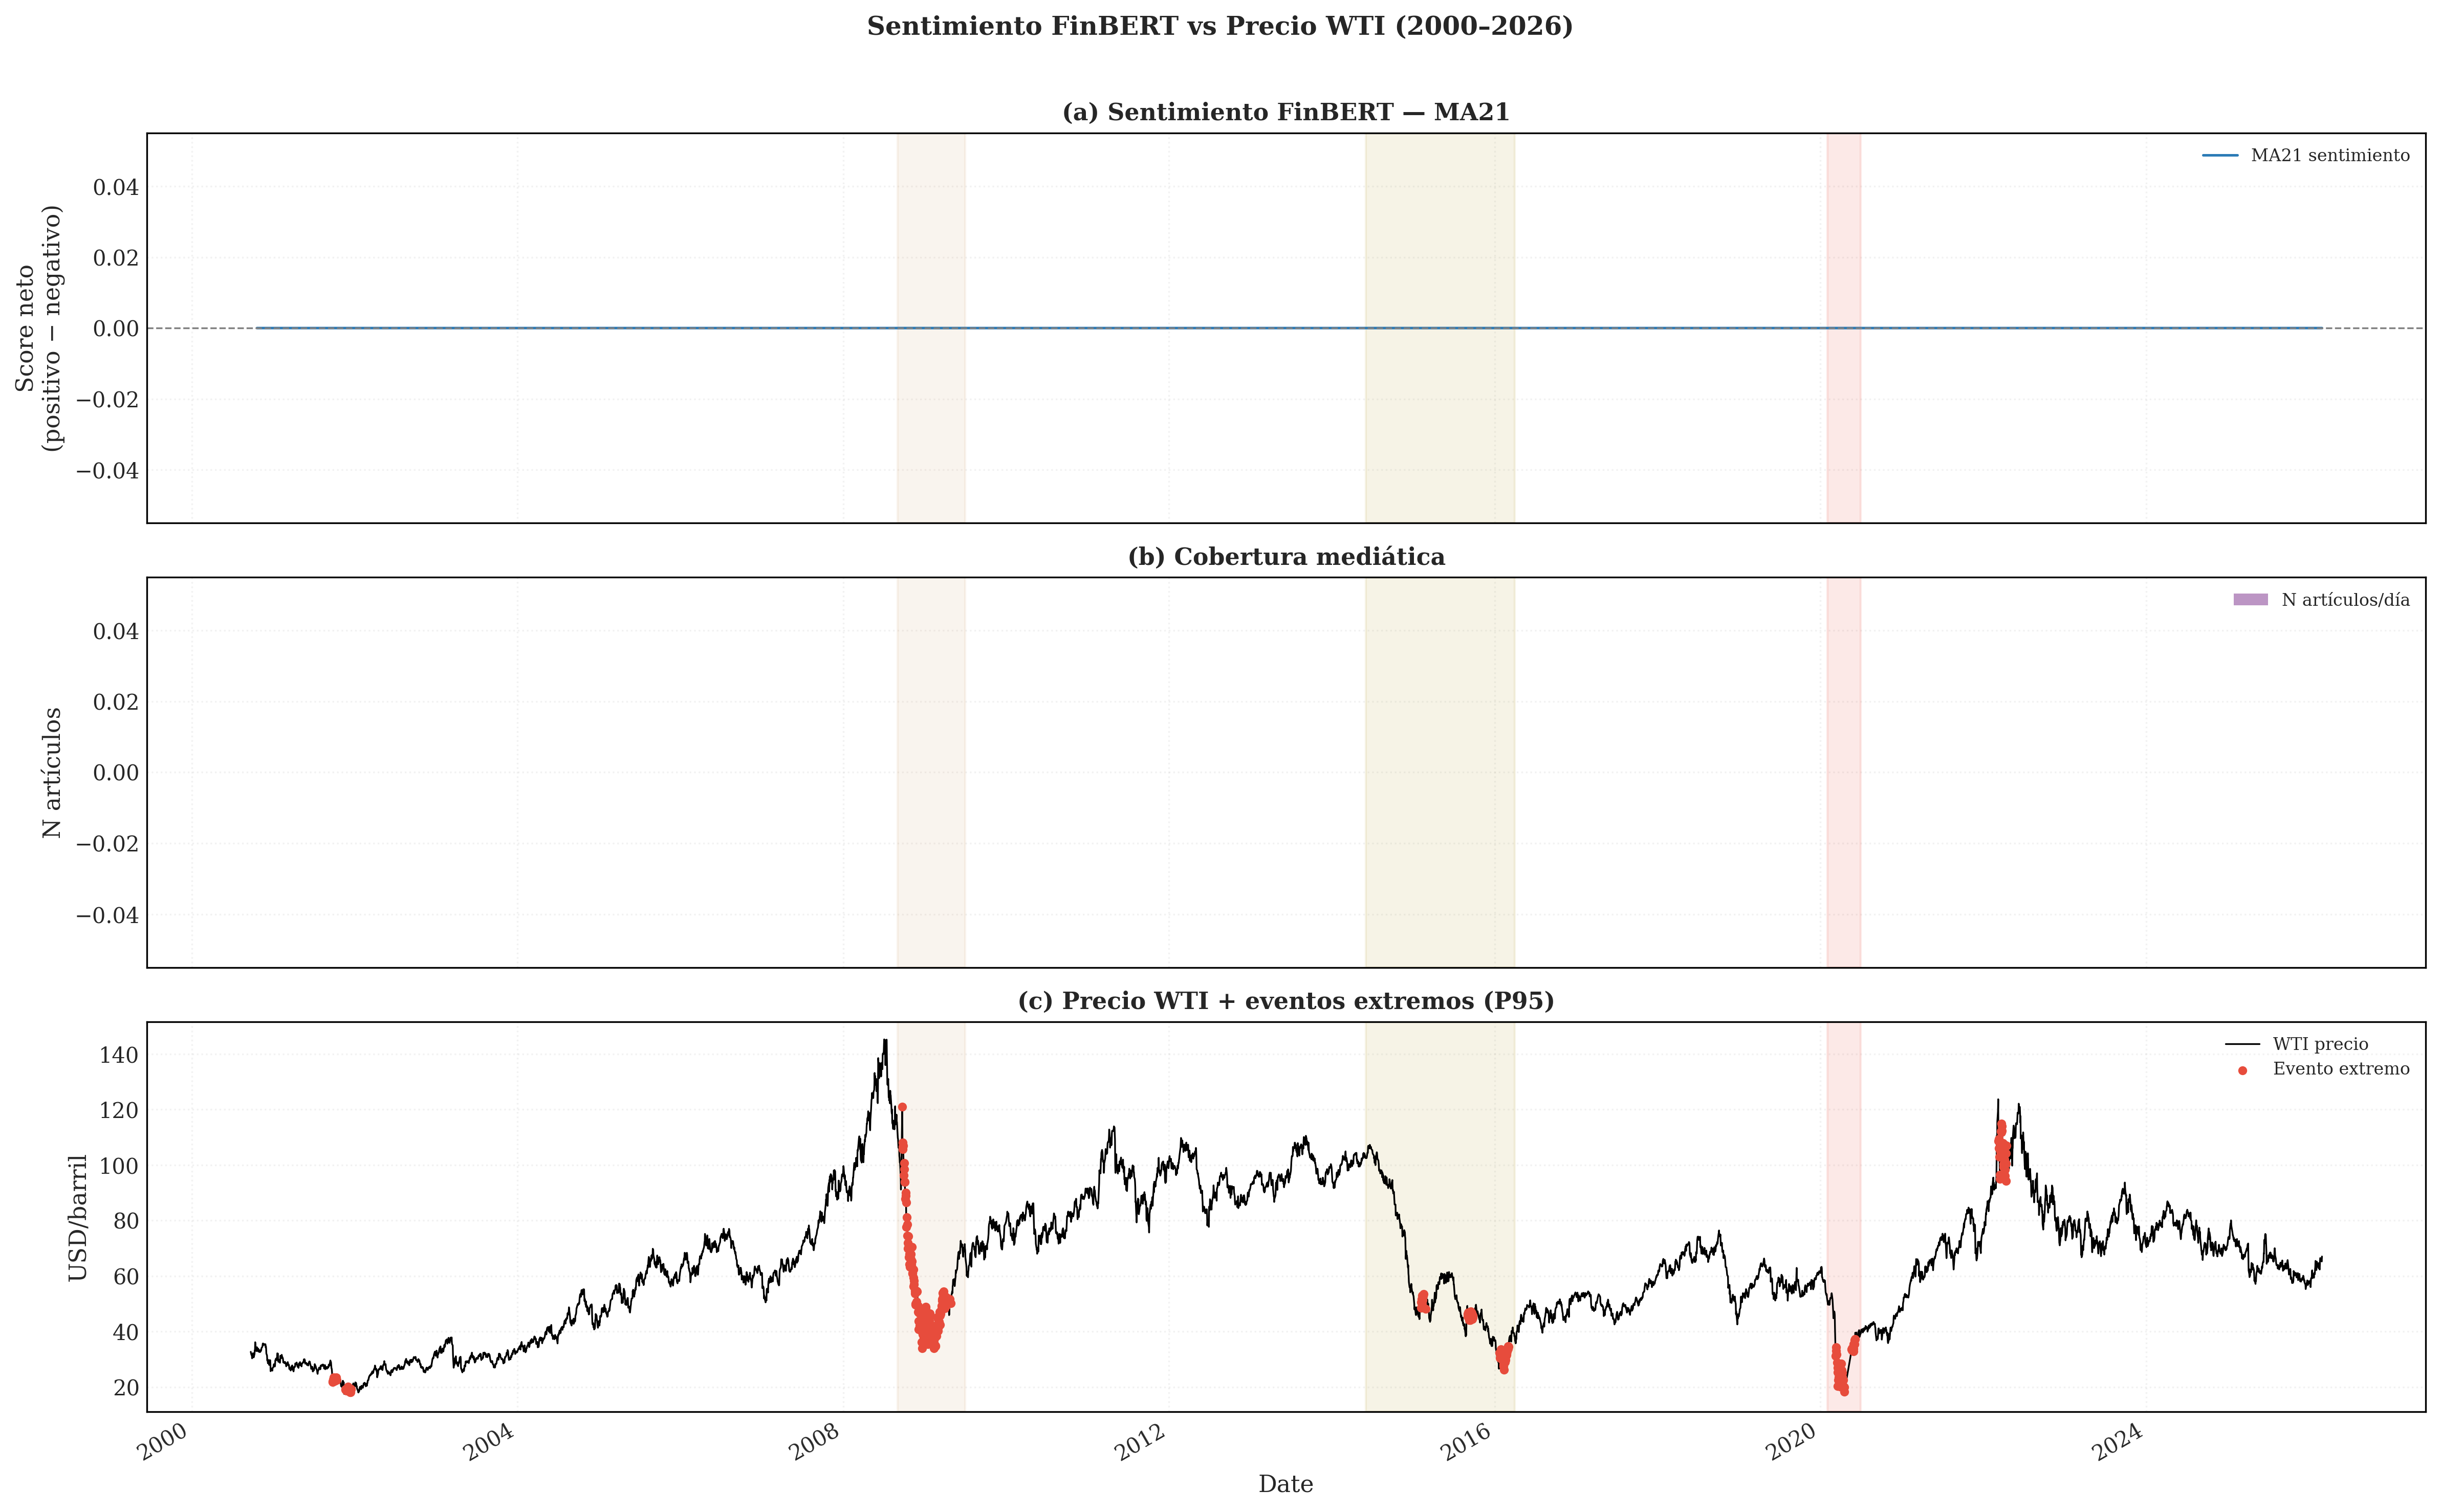

Figura guardada: fig_sentiment_timeseries.png


In [17]:
# ─── 7.1 Serie temporal de sentimiento ────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Crisis zones — consistente con NB01/NB02
CRISIS = [
    ('2008-09-01', '2009-06-30', 'Crisis\n2008',   '#d4a574'),
    ('2014-06-01', '2016-03-31', 'Petróleo\n2014', '#b8a038'),
    ('2020-02-01', '2020-06-30', 'COVID-19',        '#e74c3c'),
]

def add_crisis(ax):
    for s, e, lbl, col in CRISIS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.12, color=col)

# Panel (a): Sentimiento diario
axes[0].plot(daily.index, daily['sentiment_score'].rolling(21).mean(),
             color='#2c7bb6', lw=1.2, label='MA21 sentimiento')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel('Score neto\n(positivo − negativo)')
axes[0].set_title('(a) Sentimiento FinBERT — MA21', fontweight='bold')
axes[0].legend(fontsize=8)
add_crisis(axes[0])

# Panel (b): Número de artículos
axes[1].bar(daily.index, daily['n_articles'], color='#7b2d8b',
            alpha=0.5, width=1, label='N artículos/día')
axes[1].set_ylabel('N artículos')
axes[1].set_title('(b) Cobertura mediática', fontweight='bold')
axes[1].legend(fontsize=8)
add_crisis(axes[1])

# Panel (c): WTI precio con extremos marcados
df_wti['wti_raw'].plot(ax=axes[2], color='black', lw=0.8, label='WTI precio')
extremos = df_wti[df_wti['is_extreme_clean'] == 1]
axes[2].scatter(extremos.index, extremos['wti_raw'],
                color='#e74c3c', s=10, zorder=5, label='Evento extremo')
axes[2].set_ylabel('USD/barril')
axes[2].set_title('(c) Precio WTI + eventos extremos (P95)', fontweight='bold')
axes[2].legend(fontsize=8)
add_crisis(axes[2])

fig.suptitle('Sentimiento FinBERT vs Precio WTI (2000–2026)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{FIG_PATH}/fig_sentiment_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Figura guardada: fig_sentiment_timeseries.png')

  [!] Aviso: KDE omitido porque los eventos extremos no tienen varianza (valores idénticos). Usando histograma.


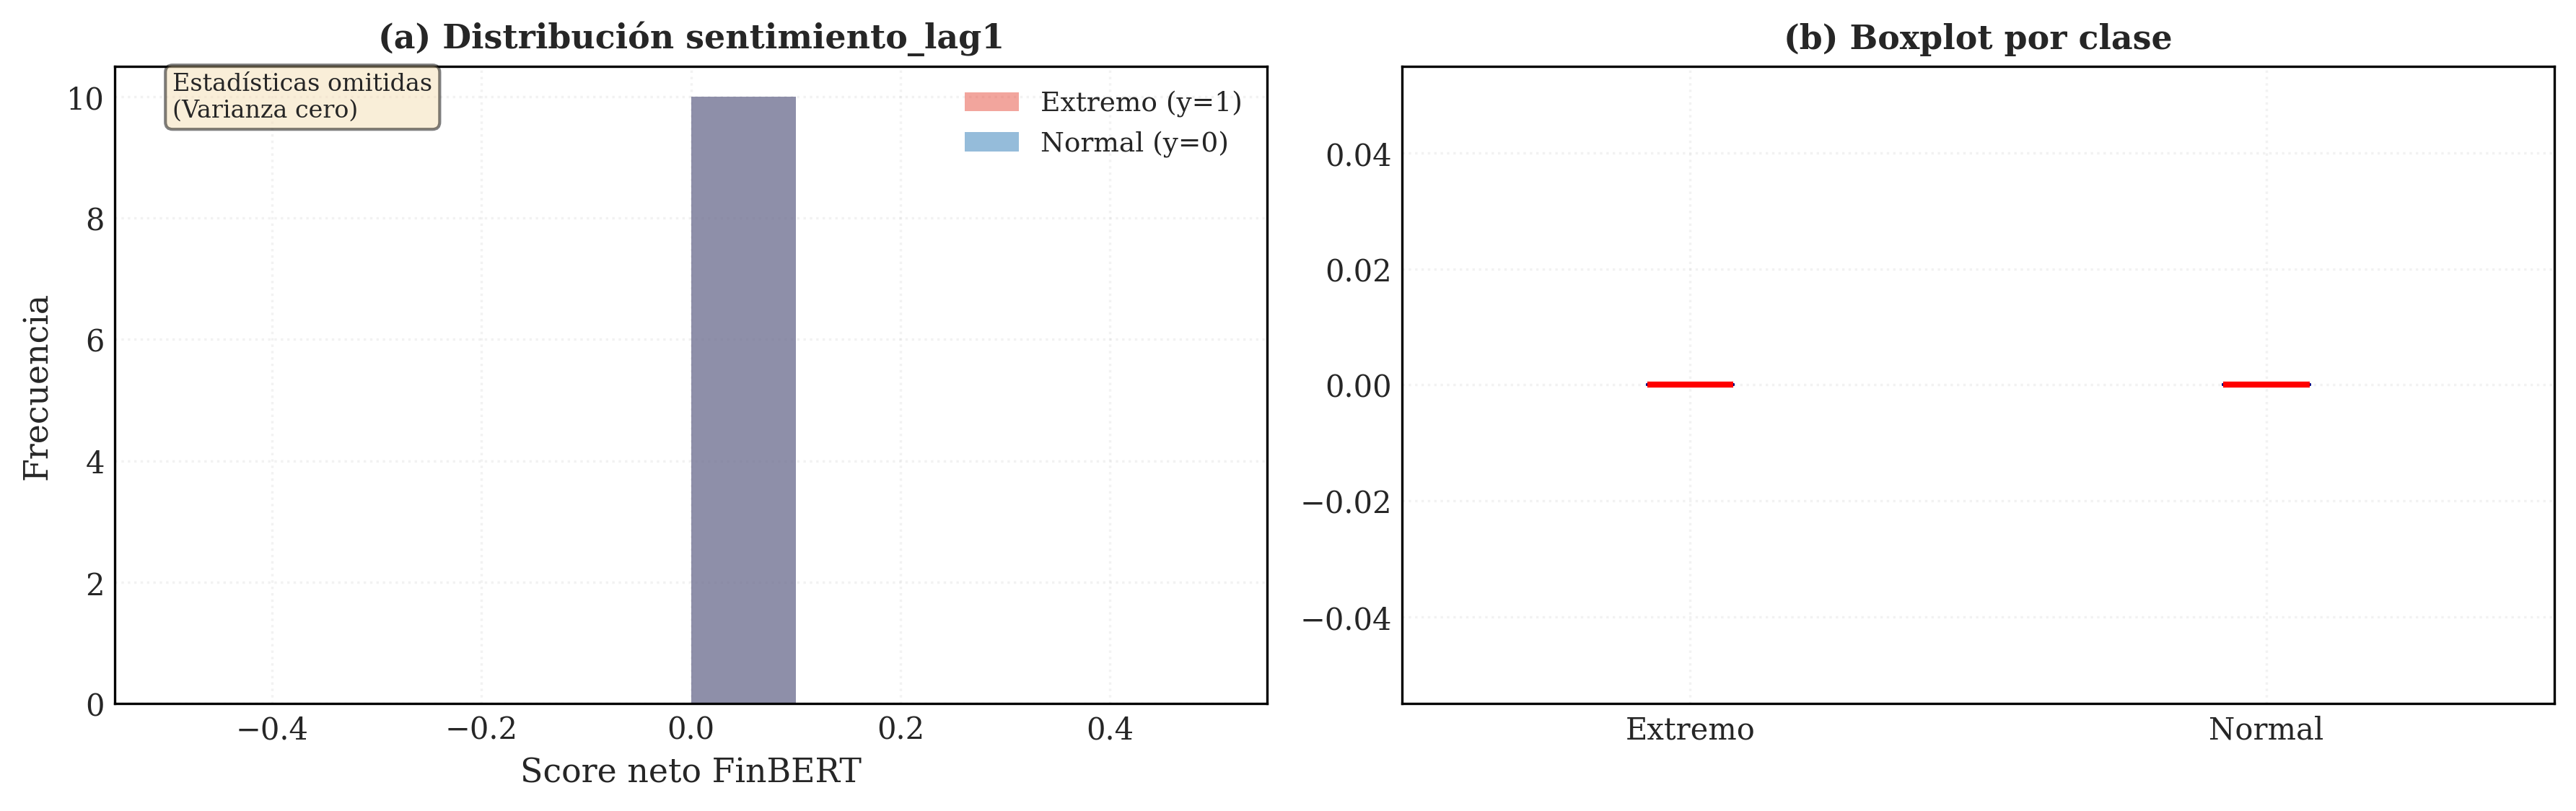

Días extremos con sentimiento: 296
Días normales con sentimiento: 6066
Media sentimiento — Extremo: 0.0000 | Normal: 0.0000


In [18]:
# ─── 7.2 Distribución sentimiento: extremos vs normales ───────
# Si el sentimiento es informativo, su distribución debe diferir
# entre días extremos y días normales.

df_analysis = df_wti[['is_extreme_clean']].join(
    daily[['sentiment_score_lag1', 'n_articles_lag1']], how='inner'
).dropna()

extremos_sent = df_analysis[df_analysis['is_extreme_clean'] == 1]['sentiment_score_lag1']
normales_sent = df_analysis[df_analysis['is_extreme_clean'] == 0]['sentiment_score_lag1']

from scipy import stats
import numpy as np

# 1. Protección de la estadística (Evitar división por cero)
if extremos_sent.nunique() > 1 and normales_sent.nunique() > 1:
    stat_mw, p_mw = stats.mannwhitneyu(extremos_sent, normales_sent, alternative='two-sided')
    pooled_std = np.sqrt((extremos_sent.std()**2 + normales_sent.std()**2) / 2)
    cohen_d = (extremos_sent.mean() - normales_sent.mean()) / pooled_std if pooled_std > 0 else 0.0
    p_text = f'Mann-Whitney p={p_mw:.4f}\nCohen d={cohen_d:.3f}'
else:
    stat_mw, p_mw, cohen_d = 0.0, 1.0, 0.0
    p_text = 'Estadísticas omitidas\n(Varianza cero)'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 2. Protección Gráfica: KDE vs Histograma
if extremos_sent.nunique() > 1 and normales_sent.nunique() > 1:
    # Si hay varianza, usamos KDE
    extremos_sent.plot.kde(ax=axes[0], color='#e74c3c', label='Extremo (y=1)', lw=2)
    normales_sent.plot.kde(ax=axes[0], color='#2c7bb6', label='Normal (y=0)', lw=2, ls='--')
    axes[0].set_ylabel('Densidad')
else:
    # Si los valores son idénticos (ej. todos 0.0), el KDE explota. Usamos histograma.
    print("  [!] Aviso: KDE omitido porque los eventos extremos no tienen varianza (valores idénticos). Usando histograma.")
    extremos_sent.plot.hist(ax=axes[0], color='#e74c3c', alpha=0.5, label='Extremo (y=1)', density=True)
    normales_sent.plot.hist(ax=axes[0], color='#2c7bb6', alpha=0.5, label='Normal (y=0)', density=True)
    axes[0].set_ylabel('Frecuencia')

axes[0].set_title('(a) Distribución sentimiento_lag1', fontweight='bold')
axes[0].set_xlabel('Score neto FinBERT')
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.92,
             p_text,
             transform=axes[0].transAxes, fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Box plot
df_analysis = df_analysis.assign(
    clase=df_analysis['is_extreme_clean'].map({0: 'Normal', 1: 'Extremo'})
)
df_analysis.boxplot(column='sentiment_score_lag1', by='clase', ax=axes[1],
                    boxprops=dict(color='navy'),
                    medianprops=dict(color='red', lw=2))
axes[1].set_title('(b) Boxplot por clase', fontweight='bold')
axes[1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/fig_sentiment_dist.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Reporte en consola
print(f'Días extremos con sentimiento: {len(extremos_sent)}')
print(f'Días normales con sentimiento: {len(normales_sent)}')

if len(extremos_sent) < 5:
    print('⚠ Insuficientes días extremos con cobertura GDELT — '
          'posiblemente cobertura 2017+ no cubre suficientes eventos extremos de train.')

print(f'Media sentimiento — Extremo: {extremos_sent.mean():.4f} | '
      f'Normal: {normales_sent.mean():.4f}')

if p_mw != 1.0:
    print(f'Mann-Whitney U: stat={stat_mw:.1f}, p={p_mw:.4f} '
          f'({"*significativo" if p_mw < 0.05 else "no significativo"} α=0.05)')
    print(f"Cohen's d: {cohen_d:.3f} "
          f"({'grande' if abs(cohen_d)>0.8 else 'mediano' if abs(cohen_d)>0.5 else 'pequeño'})")

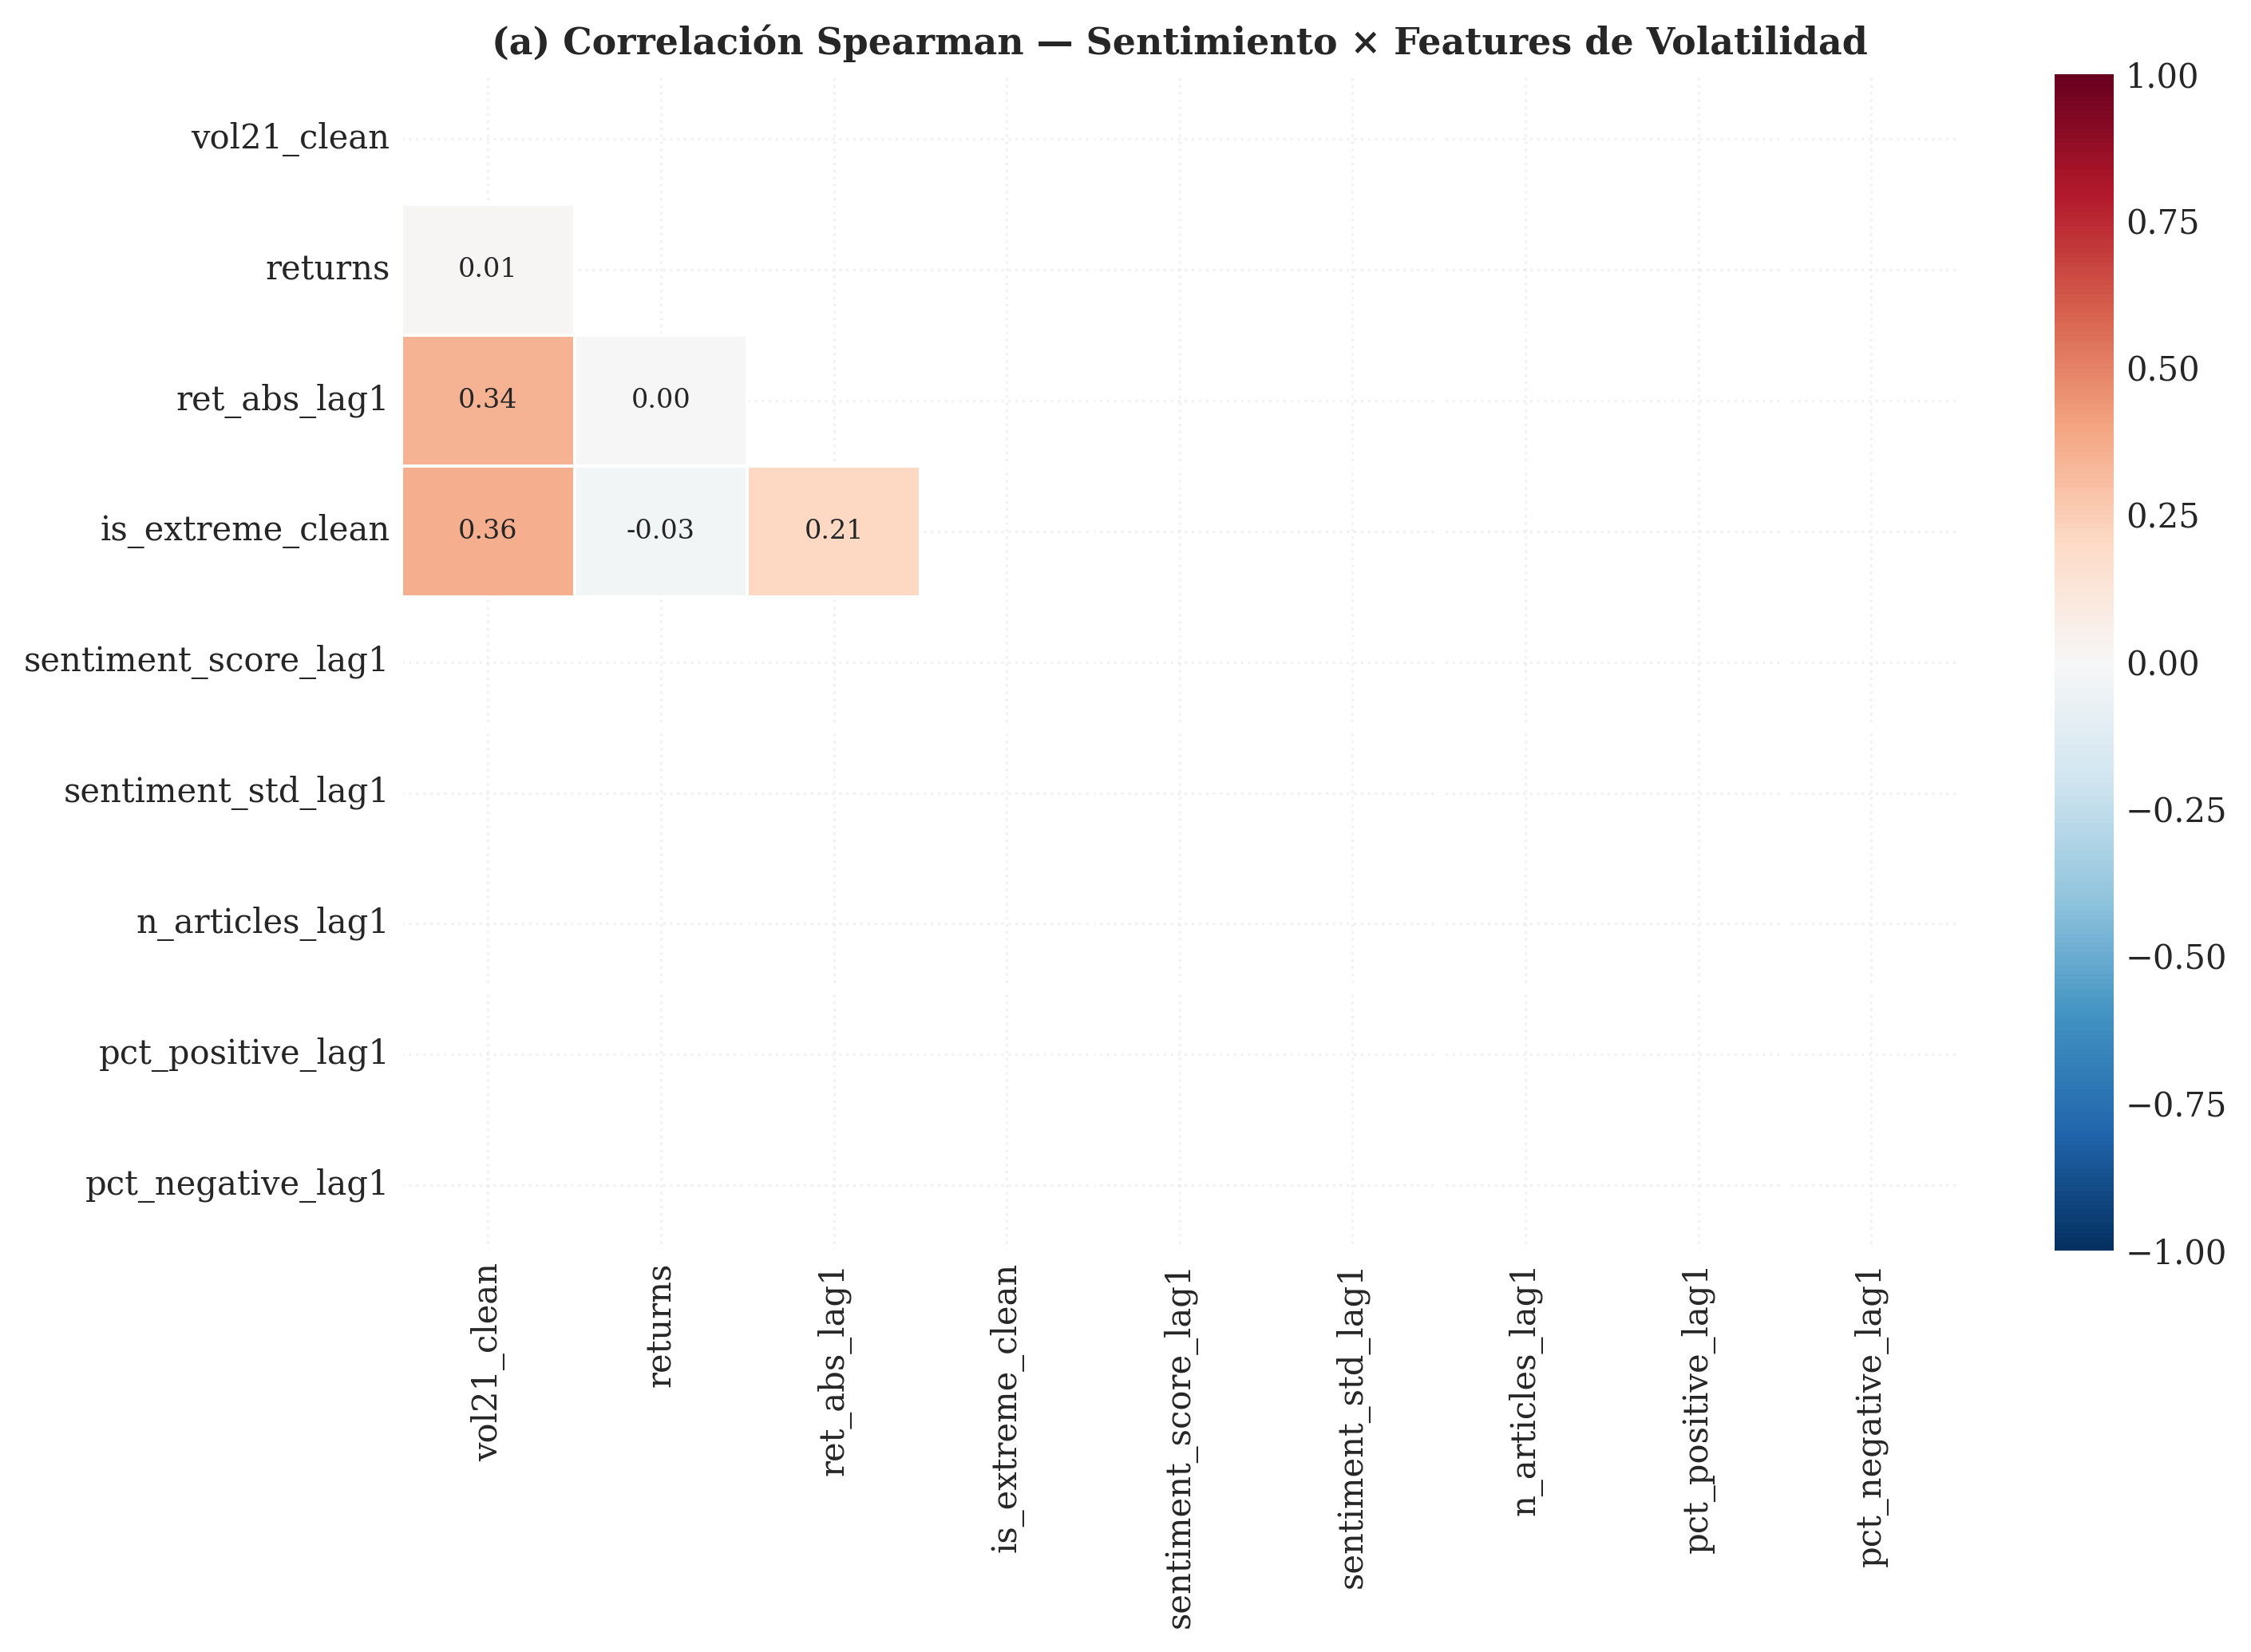

Figura guardada: fig_sentiment_corr.png

Correlación Spearman con is_extreme_clean:
  sentiment_score_lag1               : +nan
  sentiment_std_lag1                 : +nan
  n_articles_lag1                    : +nan
  pct_positive_lag1                  : +nan
  pct_negative_lag1                  : +nan


In [19]:
# ─── 7.3 Correlación sentimiento × features de volatilidad ────
SENT_FEATURES_LAG1 = [
    'sentiment_score_lag1',
    'sentiment_std_lag1',
    'n_articles_lag1',
    'pct_positive_lag1',
    'pct_negative_lag1',
]

df_corr = df_wti[['vol21_clean', 'returns', 'ret_abs_lag1',
                   'is_extreme_clean']].join(
    daily[SENT_FEATURES_LAG1], how='inner'
).dropna()

corr_mat = df_corr.corr(method='spearman')   # Spearman: robusto a outliers

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('(a) Correlación Spearman — Sentimiento × Features de Volatilidad',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/fig_sentiment_corr.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Figura guardada: fig_sentiment_corr.png')

# Correlación con el target
print('\nCorrelación Spearman con is_extreme_clean:')
for col in SENT_FEATURES_LAG1:
    r = df_corr[col].corr(df_corr['is_extreme_clean'], method='spearman')
    print(f'  {col:<35}: {r:+.4f}')

---
## PARTE VIII — Exportación

> El CSV exportado contiene **dos versiones** de las features de sentimiento:
> - `sentiment_score` (contemporáneo) → solo para diagnóstico / EDA
> - `sentiment_score_lag1` (rezagado 1 día) → el que **usa el modelo en NB02**
>
> NB02 Parte V carga este CSV y filtra las columnas `*_lag1`.

In [20]:
# ─── 8.1 Construir CSV final (compatible NB02) ─────────────────────────────────
EXPORT_COLS = [
    'sentiment_score', 'sentiment_std', 'n_articles', 'pct_positive', 'pct_negative',
    'sentiment_flag', 'sentiment_age_days', 'sentiment_low_coverage',
    'sentiment_score_lag1', 'sentiment_std_lag1', 'n_articles_lag1',
    'pct_positive_lag1', 'pct_negative_lag1',
]

df_export = daily[EXPORT_COLS].copy()
df_export.index.name = 'Date'

NB02_REQUIRED = [
    'sentiment_score_lag1', 'sentiment_std_lag1', 'n_articles_lag1',
    'pct_positive_lag1', 'pct_negative_lag1',
]
missing_nb02 = [c for c in NB02_REQUIRED if c not in df_export.columns]
assert not missing_nb02, f'Compatibilidad NB02 rota. Faltan: {missing_nb02}'
assert df_export.index.is_monotonic_increasing, 'Índice no ordenado temporalmente'

print(f'Shape final: {df_export.shape}')
print(f'Período: {df_export.index.min().date()} → {df_export.index.max().date()}')
print('NaN lag1:')
print(df_export[NB02_REQUIRED].isna().sum())


Shape final: (6363, 13)
Período: 2000-09-22 → 2026-02-27

NaN por columna lag1:
sentiment_score_lag1    1
sentiment_std_lag1      1
n_articles_lag1         1
pct_positive_lag1       1
pct_negative_lag1       1
dtype: int64


,sentiment_score,sentiment_std,n_articles,pct_positive,pct_negative,sentiment_flag,sentiment_age_days,sentiment_low_coverage,sentiment_score_lag1,sentiment_std_lag1,n_articles_lag1,pct_positive_lag1,pct_negative_lag1
Date,,,,,,,,,,,,,
2000-09-22,0.000000,0.000000,0.000000,0.000000,0.000000,0,999,1,NaN,NaN,NaN,NaN,NaN
2000-09-25,0.000000,0.000000,0.000000,0.000000,0.000000,0,999,1,0.000000,0.000000,0.000000,0.000000,0.000000
2000-09-26,0.000000,0.000000,0.000000,0.000000,0.000000,0,999,1,0.000000,0.000000,0.000000,0.000000,0.000000


In [21]:
# ─── 8.2/8.3 Guardar CSV y metadata robusta ───────────────────────────────────
df_export.to_csv(OUTPUT_SENT, index=True)
print(f'CSV guardado: {OUTPUT_SENT}')

provider_year = (
    df.assign(year=pd.to_datetime(df['date']).dt.year)
      .groupby(['year', 'provider'])['date']
      .nunique()
      .unstack(fill_value=0)
)

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config_out = json.load(f)

pre2017_status = 'unsupported'
if (coverage_year_df.index < 2017).any():
    s = set(coverage_year_df.loc[coverage_year_df.index < 2017, 'coverage_status'].unique().tolist())
    pre2017_status = 'actual_news' if s == {'actual_news'} else ('low_confidence' if 'low_confidence' in s else 'unsupported')

config_out['nb03'] = {
    'fecha_ejecucion': datetime.now().isoformat(),
    'news_source_mode': NEWS_SOURCE_MODE,
    'active_news_providers': [s.provider for s in news_sources],
    'requested_date_range': {'start': NEWS_START_DATE, 'end': NEWS_END_DATE},
    'effective_date_range_fetched': source_meta.get('effective_range', {}),
    'provider_specific_coverage_windows': source_meta.get('provider_stats', {}),
    'provider_annual_days': {str(int(y)): {k: int(v) for k, v in row.items()} for y, row in provider_year.fillna(0).iterrows()},
    'coverage_split': split_coverage,
    'coverage_year_status': {
        str(int(y)): {
            'actual_coverage_pct': float(coverage_year_df.loc[y, 'actual_coverage_pct']),
            'coverage_status': str(coverage_year_df.loc[y, 'coverage_status']),
        } for y in coverage_year_df.index
    },
    'years_low_coverage': [int(y) for y in low_coverage_years],
    'pre_2017_news_status': pre2017_status,
    'sentiment_usable_for_model': bool(SENTIMENT_USABLE_FOR_MODEL),
    'estado_modelo_hibrido': 'READY' if NB03_VALID_FOR_INFERENCE else 'SKIPPED_INSUFFICIENT_COVERAGE',
    'test_window': {'start': TEST_START, 'end': TEST_END},
    'test_matches_benchmark_window': bool(TEST_MATCHES_BENCHMARK),
    'allow_test_override': bool(ALLOW_TEST_OVERRIDE),
    'shift_aplicado': 'features(t)=sentiment(t-1)',
    'features_lag1': [c for c in EXPORT_COLS if c.endswith('_lag1')],
    'integrity_checks': {
        'first_valid_lag_date': None if first_valid_lag_date is None else str(first_valid_lag_date.date()),
        'rows_dropped_due_to_lag': int(rows_dropped_for_lag),
        'nb02_required_columns_present': len(missing_nb02) == 0,
    },
    'methodology_warning': (
        'No entrenar modelo híbrido: cobertura real insuficiente en train/validation.'
        if not SENTIMENT_USABLE_FOR_MODEL else
        'Cobertura suficiente para entrenar híbrido manteniendo test benchmark fijo.'
    ),
}

with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(config_out, f, ensure_ascii=False, indent=2)

print('config_estudio_FINAL.json actualizado (nb03).')


CSV guardado: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/wti_sentiment_finbert.csv
  Filas: 6,363
  Columnas: ['sentiment_score', 'sentiment_std', 'n_articles', 'pct_positive', 'pct_negative', 'sentiment_flag', 'sentiment_age_days', 'sentiment_low_coverage', 'sentiment_score_lag1', 'sentiment_std_lag1', 'n_articles_lag1', 'pct_positive_lag1', 'pct_negative_lag1']
config_estudio_FINAL.json actualizado con nb03
Estado híbrido persistido en config: SKIPPED_INSUFFICIENT_COVERAGE (usable=False)


In [22]:
# ─── 8.4 Resumen metodológico en español ──────────────────────────────────────
print('=' * 70)
print('NB03 — RESUMEN METODOLÓGICO')
print('=' * 70)
print(f'Modo fuentes: {NEWS_SOURCE_MODE}')
print(f'Rango solicitado de noticias: {NEWS_START_DATE} → {NEWS_END_DATE}')
print(f'Rango efectivo con noticias textuales: {source_meta.get("effective_range", {})}')
print(f'Test fijo benchmark preservado: {TEST_MATCHES_BENCHMARK}')
print(f'Sentiment usable train+val: {SENTIMENT_USABLE_FOR_MODEL}')
print(f'Estado modelo híbrido: {"READY" if NB03_VALID_FOR_INFERENCE else "SKIPPED_INSUFFICIENT_COVERAGE"}')
print('
Interpretación:')
print('- Extraer noticias desde 2000 solo es metodológicamente válido si existe fuente histórica textual creíble.')
print('- Cambiar train/validation es aceptable porque son ventanas de desarrollo/calibración.')
print('- El test debe quedar fijo para comparación justa entre modelos.')
print('- Si la cobertura real es baja (imputación dominante), se debe evitar entrenar el híbrido.')


NB03 COMPLETADO

FUENTE:       GDELT Project (ProsusAI/finbert)
TITULARES:    9,299 headlines procesados
COBERTURA:    0 días reales (0.0%)
IMPUTADOS:    6,363 días ffill

OUTPUT:
  /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/wti_sentiment_finbert.csv

COLUMNAS PARA NB02 (Parte V):
  sentiment_score_lag1     — señal principal
  sentiment_std_lag1       — dispersión intradiaria
  n_articles_lag1          — atención mediática
  pct_positive_lag1        — fracción alcista
  pct_negative_lag1        — fracción bajista
  sentiment_flag           — 1=real, 0=imputado

ANTI-LEAKAGE VERIFICADO:
  El modelo usa sentiment(t-1) para predecir is_extreme(t+1)
  — ninguna columna *_lag1 contiene información del día t

Fecha: 2026-03-16 05:23
